# Spatial Equilibrium Model — Interactive Notebook
**Based on:** *Spatial Economics for Granular Settings*, Sections 2.1–2.2

This notebook lets you:
- Adjust model parameters with **sliders**
- Instantly re-solve the spatial equilibrium
- Visualize wages, rents, population, commuting flows, and comparative statics

> **How to use:** Run all cells (Cell → Run All), then drag the sliders in the Interactive Dashboard section and press **Solve Model**.

In [21]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
from typing import Optional
import ipywidgets as widgets
from IPython.display import display, clear_output

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 10
print('Imports OK')

Imports OK


## Model Classes
*Run these cells to load the model — no output expected.*

In [22]:
class Location:
    """
    A single geographic location.
    Holds fixed primitives (A, T) and equilibrium objects
    (wage, rent, population, labor_supply, income) updated
    in-place by the solver each iteration.
    """
    def __init__(self, location_id, productivity, land_supply):
        self.id           = location_id
        self.A            = productivity  # total factor productivity
        self.T            = land_supply   # fixed land endowment
        self.wage         = 1.0
        self.rent         = 1.0
        self.population   = 0.0
        self.labor_supply = 0.0
        self.income       = 0.0

    def update_wage(self, new_wage, damping=0.8):
        self.wage = damping * new_wage + (1.0 - damping) * self.wage

    def update_rent(self, new_rent, damping=0.8):
        self.rent = damping * new_rent + (1.0 - damping) * self.rent

    def update_population_stats(self, population, labor_supply, income):
        self.population   = population
        self.labor_supply = labor_supply
        self.income       = income

    def __repr__(self):
        return (f'Location(id={self.id}, A={self.A:.3f}, T={self.T:.3f}, '
                f'w={self.wage:.4f}, r={self.rent:.4f})')

print('Location class loaded.')

Location class loaded.


In [23]:
class SpatialModel:
    """
    The full spatial economy: N Location objects + N x N commuting cost matrix.
    Generates all exogenous primitives and exposes the core computations
    (commuting shares, CES price index) needed by the solver.
    """
    def __init__(self, N, alpha, sigma, epsilon, L=1.0, seed=42):
        assert N >= 2
        assert 0 < alpha < 1
        assert sigma > 1
        assert epsilon > 0
        self.N, self.alpha, self.sigma = N, alpha, sigma
        self.epsilon, self.L = epsilon, L
        self.rng = np.random.default_rng(seed)
        self._check_existence()
        self._generate_primitives()

    def _check_existence(self):
        v = self.existence_value()
        if v > 0.5:
            warnings.warn(f'Existence condition NOT satisfied: {v:.4f} > 0.5')

    def existence_value(self):
        a = (1 + self.epsilon) / (self.sigma + self.epsilon)
        b = (self.alpha * self.epsilon) / (1 + self.alpha * self.epsilon)
        return a * b

    def _generate_primitives(self):
        N = self.N
        # Productivity: Pareto, shift so A >= 1, then pin A[0] = 1
        # Every other location's productivity is a multiple of location 0's
        A_raw = self.rng.pareto(a=2.0, size=N) + 1.0
        A     = A_raw / A_raw[0]
        # Land supply: Uniform, pin T[0] = 1
        # Every other location's land is a multiple of location 0's endowment
        T_raw = self.rng.uniform(0.5, 1.5, size=N)
        T     = T_raw / T_raw[0]
        self.locations = [Location(i, A[i], T[i]) for i in range(N)]
        # Commuting costs: shifted lognormal, all off-diagonal values in [1, 2]
        # Enforces delta_kn >= 1 so commuting is always a cost, never a discount
        raw       = np.exp(self.rng.normal(0.0, 0.3, (N, N)))
        off_min   = raw.min()
        off_range = raw.max() - off_min
        if off_range > 1e-10:
            self.delta = 1.0 + (raw - off_min) / off_range
        else:
            self.delta = np.ones((N, N))
        np.fill_diagonal(self.delta, 1.0)
        assert self.delta.min() >= 1.0

    # ── properties ────────────────────────────────────────────────
    @property
    def wages(self):          return np.array([l.wage for l in self.locations])
    @property
    def rents(self):          return np.array([l.rent for l in self.locations])
    @property
    def productivities(self): return np.array([l.A    for l in self.locations])
    @property
    def land_supplies(self):  return np.array([l.T    for l in self.locations])

    # ── core computations ─────────────────────────────────────────
    def compute_price_index(self):
        """CES price index: P = [sum_n (w_n/A_n)^(1-sigma)]^(1/(1-sigma))"""
        w, A = self.wages, self.productivities
        return np.sum((w / A) ** (1 - self.sigma)) ** (1 / (1 - self.sigma))

    def compute_commuting_shares(self):
        """Equation (2): N x N matrix of commuting shares summing to 1."""
        w, r     = self.wages, self.rents
        e, a     = self.epsilon, self.alpha
        w_term   = w[np.newaxis, :] ** e
        r_term   = (r[:, np.newaxis] ** a * self.delta) ** (-e)
        num      = w_term * r_term
        return num / num.sum()

    def update_locations_from_flows(self, flows):
        """Push population statistics into each Location object."""
        w  = self.wages
        ef = flows / self.delta  # time-adjusted flows
        for k, loc in enumerate(self.locations):
            loc.update_population_stats(
                population   = flows[k, :].sum(),
                labor_supply = ef[:, k].sum(),
                income       = (w * ef[k, :]).sum()
            )

print('SpatialModel class loaded.')

SpatialModel class loaded.


In [24]:
class EquilibriumSolver:
    """
    Finds equilibrium wages {w_n} and rents {r_k} via damped fixed-point
    iteration, implementing goods market clearing (Eq. 3) and land market
    clearing (Eq. 4) from the paper.
    """
    def __init__(self, model, tol=1e-8, max_iter=10_000, damping=0.8):
        self.model, self.tol   = model, tol
        self.max_iter, self.damping = max_iter, damping
        self.converged        = False
        self.iterations_taken = 0
        self.wage_history     = []
        self.commuting_flows  = None

    def solve(self):
        """Run iteration until convergence. Returns True if converged."""
        m = self.model
        # Initialise
        for loc in m.locations:
            loc.wage = 1.0
            loc.rent = 1.0

        for it in range(1, self.max_iter + 1):
            old_w = m.wages.copy()
            old_r = m.rents.copy()

            # Step 1 — commuting flows from Eq (2)
            flows = m.compute_commuting_shares() * m.L
            m.update_locations_from_flows(flows)

            # Step 2 — wage update from goods market clearing (Eq 3)
            nw = self._update_wages()
            # Step 3 — rent update from land market clearing (Eq 4)
            nr = self._update_rents()

            # Step 4 — apply damped updates
            for i, loc in enumerate(m.locations):
                loc.update_wage(nw[i], self.damping)
                loc.update_rent(nr[i], self.damping)

            # Step 5 — normalize price level
            self._normalize()

            # Step 6 — check convergence
            chg = max(np.max(np.abs(m.wages - old_w)),
                      np.max(np.abs(m.rents - old_r)))
            self.wage_history.append(chg)
            if chg < self.tol:
                self.converged, self.iterations_taken = True, it
                break

        # Final flows at converged wages/rents
        self.commuting_flows = m.compute_commuting_shares() * m.L
        m.update_locations_from_flows(self.commuting_flows)
        return self.converged

    def _update_wages(self):
        """Proportional update: move wages toward goods-market balance."""
        m    = self.model
        w, A = m.wages, m.productivities
        P    = m.compute_price_index()
        Y    = sum(l.wage * l.labor_supply for l in m.locations)
        supply = np.maximum(np.array([l.A * l.labor_supply for l in m.locations]), 1e-12)
        demand = (w / A) ** (-m.sigma) / P ** (1 - m.sigma) * Y
        return w * (demand / supply) ** (1 / m.sigma)

    def _update_rents(self):
        """Direct formula from land market clearing (Eq. 4): r_k = alpha/T_k * sum_n y_kn"""
        m  = self.model
        nr = np.array([(m.alpha / l.T) * l.income for l in m.locations])
        return np.maximum(nr, 1e-12)

    def _normalize(self):
        """Pin w[0] = 1 each iteration — all wages expressed as multiples
        of location 0's wage.  e.g. w[3] = 1.4 means loc 3 pays 40% more."""
        w0 = self.model.locations[0].wage
        if w0 > 1e-12:
            for l in self.model.locations:
                l.wage /= w0

print('EquilibriumSolver class loaded.')

EquilibriumSolver class loaded.


In [25]:
def find_optimal_damping(N=10, alpha=0.25, sigma=4.0, epsilon=2.0, seed=42,
                         damping_values=None):
    """
    Tests a range of damping values on the same model and reports:
      - whether the solver converged
      - how many iterations it took
      - the final convergence residual
    Prints results as plain text and returns the best damping value found.
    """
    if damping_values is None:
        damping_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    print()
    print('=' * 60)
    print('  DAMPING SEARCH')
    print(f'  N={N}  alpha={alpha}  sigma={sigma}  epsilon={epsilon}  seed={seed}')
    print('=' * 60)
    print(f'  {"Damping":>10}  {"Converged":>10}  {"Iterations":>12}  {"Final residual":>16}')
    print('-' * 60)

    results = []
    for d in damping_values:
        model  = SpatialModel(N=N, alpha=alpha, sigma=sigma,
                              epsilon=epsilon, seed=seed)
        solver = EquilibriumSolver(model, tol=1e-8, max_iter=10_000, damping=d)
        solver.solve()

        final_residual = solver.wage_history[-1] if solver.wage_history else float('nan')

        print(f'  {d:>10.2f}  {"Yes" if solver.converged else "No":>10}'
              f'  {solver.iterations_taken:>12}  {final_residual:>16.2e}')

        results.append({
            'damping'       : d,
            'converged'     : solver.converged,
            'iterations'    : solver.iterations_taken,
            'final_residual': final_residual,
        })

    # Find best: converged solutions only, ranked by fewest iterations
    converged = [r for r in results if r['converged']]
    if converged:
        best = min(converged, key=lambda r: r['iterations'])
        print('-' * 60)
        print(f'  Best damping value : {best["damping"]:.2f}')
        print(f'  Iterations taken   : {best["iterations"]}')
        print(f'  Final residual     : {best["final_residual"]:.2e}')
    else:
        best = None
        print('-' * 60)
        print('  No damping value converged within max_iter.')
        print('  Try increasing max_iter or adjusting parameters.')

    print('=' * 60)
    return best['damping'] if best else None


# --- Run it ---
optimal_damping = find_optimal_damping(
    N=10, alpha=0.25, sigma=4.0, epsilon=2.0, seed=42
)


  DAMPING SEARCH
  N=10  alpha=0.25  sigma=4.0  epsilon=2.0  seed=42
     Damping   Converged    Iterations    Final residual
------------------------------------------------------------
        0.10         Yes           160          9.69e-09
        0.20         Yes            80          8.08e-09
        0.30         Yes            51          9.88e-09
        0.40         Yes            37          7.56e-09
        0.50         Yes            28          6.83e-09
        0.60         Yes            22          4.84e-09
        0.70         Yes            17          5.54e-09
        0.80         Yes            15          7.18e-09
        0.90         Yes            23          5.56e-09
------------------------------------------------------------
  Best damping value : 0.80
  Iterations taken   : 15
  Final residual     : 7.18e-09


In [27]:
class SpatialAnalysis:
    """Summary statistics and comparative statics on a solved model."""
    def __init__(self, model, solver):
        self.model, self.solver = model, solver

    def summary(self):
        m = self.model
        return {
            'wages'       : m.wages,
            'rents'       : m.rents,
            'populations' : np.array([l.population   for l in m.locations]),
            'labor'       : np.array([l.labor_supply  for l in m.locations]),
            'incomes'     : np.array([l.income        for l in m.locations]),
            'flows'           : self.solver.commuting_flows,
            'price_index'     : m.compute_price_index(),
            'total_income'    : sum(l.income for l in m.locations),
            # --- normalised derived series ---
            # Fraction of a co-located worker's wage spent on rent
            'rent_wage_ratio' : m.rents / m.wages,
            # Population relative to equal-share benchmark (1/N)
            # 1.0 = exactly equal share; 1.5 = 50% above equal share
            'pop_index'       : (np.array([l.population for l in m.locations])
                                 / (m.L / m.N)),
        }

    def commuting_summary(self):
        flows = self.solver.commuting_flows
        return {
            'home_share'  : np.diag(flows).sum() / self.model.L,
            'mean_commute': (flows * self.model.delta).sum() / self.model.L,
        }

    def comparative_statics(self, parameter, values, seed=42):
        """Re-solve at each value and record mean_wage, mean_rent, home_share."""
        base = dict(N=self.model.N, alpha=self.model.alpha,
                    sigma=self.model.sigma, epsilon=self.model.epsilon,
                    L=self.model.L)
        out  = {k: [] for k in ['mean_wage', 'mean_rent', 'home_share', 'converged']}
        for v in values:
            p = base.copy()
            p[parameter] = int(v) if parameter == 'N' else float(v)
            try:
                mod = SpatialModel(**p, seed=seed)
                sol = EquilibriumSolver(mod, tol=1e-8, max_iter=5000, damping=0.8)
                sol.solve()
                an  = SpatialAnalysis(mod, sol)
                s   = an.summary()
                cs  = an.commuting_summary()
                out['mean_wage'].append(s['wages'].mean())
                out['mean_rent'].append(s['rents'].mean())
                out['home_share'].append(cs['home_share'])
                out['converged'].append(sol.converged)
            except Exception:
                for k in out: out[k].append(np.nan)
        return {k: np.array(v) for k, v in out.items()}


    def print_location_stats(self):
        """
        Print a normalised per-location statistics table.

        Normalisation anchors (all relative to Location 0):
          A index    productivity index : Loc 0 = 1.000 by construction
          T index    land supply index  : Loc 0 = 1.000 by construction
          w index    wage index         : Loc 0 = 1.000 by construction
          r/w ratio  rent / wage        : share of co-located wage spent on rent
          Pop index  pop / (L/N)        : 1.0 = equal share; >1 = above equal
        """
        m   = self.model
        s   = self.summary()
        cs  = self.commuting_summary()
        N   = m.N
        rwr = s['rent_wage_ratio']
        pi  = s['pop_index']
        W   = 96
        sep = '-' * W
        loc0 = m.locations[0]
        print()
        print('=' * W)
        print(f'  LOCATION STATISTICS  —  indices normalised to Location 0')
        print(f'  N={N}  alpha={m.alpha}  sigma={m.sigma}  epsilon={m.epsilon}')
        print(f'  Reference Loc 0:  raw A={loc0.A:.4f}  raw T={loc0.T:.4f}  wage index={loc0.wage:.4f}')
        print('=' * W)
        print(f'  {"Loc":>4}  {"A index":>8}  {"T index":>8}'
              f'  {"w index":>8}  {"Rent":>9}  {"r/w ratio":>10}'
              f'  {"Pop index":>10}  {"Income":>9}')
        print(f'  {"":>4}  {"(L0=1)":>8}  {"(L0=1)":>8}'
              f'  {"(L0=1)":>8}  {"(raw)":>9}  {"rent/wage":>10}'
              f'  {"(1=equal)":>10}  {"(raw)":>9}')
        print(sep)
        for i, loc in enumerate(m.locations):
            tag = '  <-- reference' if i == 0 else ''
            print(f'  {loc.id:>4}  {loc.A:>8.4f}  {loc.T:>8.4f}'
                  f'  {s["wages"][i]:>8.4f}  {s["rents"][i]:>9.4f}'
                  f'  {rwr[i]:>10.4f}  {pi[i]:>10.4f}'
                  f'  {s["incomes"][i]:>9.4f}{tag}')
        print(sep)
        for label, fn in [('Mean', np.mean), ('Std', np.std),
                           ('Min',  np.min),  ('Max', np.max)]:
            print(f'  {label:>4}  {fn(m.productivities):>8.4f}  {fn(m.land_supplies):>8.4f}'
                  f'  {fn(s["wages"]):>8.4f}  {fn(s["rents"]):>9.4f}'
                  f'  {fn(rwr):>10.4f}  {fn(pi):>10.4f}'
                  f'  {fn(s["incomes"]):>9.4f}')
        print('=' * W)
        print(f'  Price index P      = {s["price_index"]:.6f}')
        print(f'  Total income Y     = {s["total_income"]:.6f}')
        print(f'  Home share         = {cs["home_share"]:.2%}')
        print(f'  Mean commute cost  = {cs["mean_commute"]:.4f}')
        print(f'  Converged          = {self.solver.converged}'
              f'  ({self.solver.iterations_taken} iterations)')
        print('=' * W)

print('SpatialAnalysis class loaded.')

SpatialAnalysis class loaded.


## Visualization Helpers

In [28]:
C_WAGE = '#2563EB'
C_RENT = '#DC2626'
C_POP  = '#16A34A'


def plot_equilibrium(model, solver, fig=None):
    """
    Layout:
      Section 1 (top) — Redesigned heatmap:
          Columns = workplace locations (n), ordered 0, 1, 2, ... N-1
          Row 0   = Wage bar       (red intensity scales with wage)
          Row 1   = Rent bar       (red intensity scales with rent)
          Row 2   = Population bar (red intensity scales with population)
          Rows 3+ = Commuting flows from each residence k (row per k)
                    Cell colour = share of k-residents working in n
      Section 2 (bottom-left)  — scatter: productivity vs wage
      Section 2 (bottom-mid)   — scatter: land supply vs rent
      Section 2 (bottom-right) — convergence trace
    """
    an  = SpatialAnalysis(model, solver)
    s   = an.summary()
    cs  = an.commuting_summary()
    N   = model.N
    A   = model.productivities
    T   = model.land_supplies

    wages = s['wages']
    rents = s['rents']
    pops  = s['populations']
    flows = s['flows']                          # shape (N, N)

    # ── Natural order: locations indexed 0, 1, 2, ... N-1 ──────────────
    col_order = np.arange(N)   # no reordering
    wages_s   = wages
    rents_s   = rents
    pops_s    = pops
    flows_s   = flows

    # ── Normalise each metric to [0, 1] for colour mapping ────────
    def norm01(arr):
        lo, hi = arr.min(), arr.max()
        return (arr - lo) / (hi - lo) if hi > lo else np.zeros_like(arr)

    wage_c = norm01(wages_s)   # 0 = lowest wage, 1 = highest wage
    rent_c = norm01(rents_s)
    pop_c  = norm01(pops_s)

    # Commuting flow rows: normalise each residence row independently
    rsums      = np.where(flows_s.sum(axis=1, keepdims=True) < 1e-12,
                          1e-12, flows_s.sum(axis=1, keepdims=True))
    flow_norm  = flows_s / rsums                # row-normalised commuting shares

    # ── Build the display matrix ──────────────────────────────────
    # Rows: [wage_row, rent_row, pop_row, flow_row_0 ... flow_row_{N-1}]
    n_header = 3
    display_matrix = np.vstack([
        wage_c[np.newaxis, :],
        rent_c[np.newaxis, :],
        pop_c[np.newaxis, :],
        flow_norm
    ])  # shape (3+N, N)

    # ── Figure layout ─────────────────────────────────────────────
    # Figure grows with N: each cell gets ~0.62 inches so text always fits.
    cell_in = max(0.62, min(1.2, 12.0 / N))   # per-cell size in inches
    fig_w   = max(12, N * cell_in + 5.0)       # wide enough for N columns
    fig_h   = max(10, (n_header + N) * cell_in * 0.80 + 4.5)  # tall for rows
    if fig is None:
        fig = plt.figure(figsize=(fig_w, fig_h))
    else:
        fig.clf()

    fig.suptitle(
        f'Spatial Equilibrium  |  N={N}  alpha={model.alpha}  '
        f'sigma={model.sigma}  epsilon={model.epsilon}  '
        f'({"converged" if solver.converged else "NOT converged"}, '
        f'{solver.iterations_taken} iters)',
        fontsize=12, fontweight='bold', y=1.01
    )

    # Two-row layout: heatmap on top, three scatter plots below
    gs_outer = gridspec.GridSpec(2, 1, figure=fig,
                                  height_ratios=[n_header + N, 3],
                                  hspace=0.55)

    # ── HEATMAP ───────────────────────────────────────────────────
    ax_hm = fig.add_subplot(gs_outer[0])

    # Draw the full matrix with Reds colormap
    im = ax_hm.imshow(display_matrix, cmap='Reds', aspect='auto',
                       vmin=0, vmax=1, interpolation='nearest')

    # x-axis: workplace location labels (sorted by wage)
    ax_hm.set_xticks(np.arange(N))
    ax_hm.set_xticklabels(
        [f'Loc {col_order[j]}\nw={wages_s[j]:.2f}' for j in range(N)],
        fontsize=max(5, cell_in * 8.5), rotation=45, ha='right'
    )
    ax_hm.xaxis.set_label_position('top')
    ax_hm.xaxis.tick_top()
    ax_hm.set_xlabel('Workplace location  n',
                      fontsize=10, fontweight='bold', labelpad=10)

    # y-axis: header rows + residence rows
    ytick_labels = ['WAGE', 'RENT', 'POP'] + \
                   [f'Res {k}' for k in range(N)]
    ax_hm.set_yticks(np.arange(n_header + N))
    ax_hm.set_yticklabels(ytick_labels, fontsize=max(5, cell_in * 8.5))

    # Horizontal separator between header and flow rows
    ax_hm.axhline(n_header - 0.5, color='black', linewidth=2)

    # Left-side section labels
    ax_hm.annotate('\n', xy=(-0.01, 1 - (1.5 / (n_header + N))),
                   xycoords='axes fraction', ha='right', va='center',
                   fontsize=8, fontweight='bold', color='#374151')
    ax_hm.annotate('Commuting\nFlows', xy=(-0.01, 1 - ((n_header + N/2) / (n_header + N))),
                   xycoords='axes fraction', ha='right', va='center',
                   fontsize=8, fontweight='bold', color='#374151')

    # Cell annotations always shown; font scales with cell size
    cell_fs = max(4.5, cell_in * 10.0)  # proportional to cell size
    if True:
        # Header rows: show actual values
        for j in range(N):
            ax_hm.text(j, 0, f'{wages_s[j]:.3f}', ha='center', va='center',
                       fontsize=cell_fs,
                       color='white' if wage_c[j] > 0.6 else 'black')
            ax_hm.text(j, 1, f'{rents_s[j]:.4f}', ha='center', va='center',
                       fontsize=cell_fs,
                       color='white' if rent_c[j] > 0.6 else 'black')
            ax_hm.text(j, 2, f'{pops_s[j]:.3f}', ha='center', va='center',
                       fontsize=cell_fs,
                       color='white' if pop_c[j] > 0.6 else 'black')
        # Flow rows: show commuting share
        for i in range(N):
            for j in range(N):
                val = flow_norm[i, j]
                ax_hm.text(j, n_header + i, f'{val:.2f}',
                           ha='center', va='center', fontsize=cell_fs,
                           color='white' if val > 0.55 else 'black')

    # Colourbar
    cbar = fig.colorbar(im, ax=ax_hm, fraction=0.02, pad=0.01)
    cbar.set_label('Relative intensity  (0=low, 1=high)', fontsize=8)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Low', 'Mid', 'High'])

    ax_hm.set_title(
        f'Home share: {cs["home_share"]:.1%}  |  '
        f'Mean commute cost: {cs["mean_commute"]:.3f}  |  '
        f'Darker red = higher value',
        fontsize=9, pad=12
    )

    # ── BOTTOM ROW: three scatter / trace panels ──────────────────
    gs_bot = gridspec.GridSpecFromSubplotSpec(
        1, 3, subplot_spec=gs_outer[1], wspace=0.40)

    # productivity vs wage
    ax_s1 = fig.add_subplot(gs_bot[0])
    w_norm = Normalize(vmin=wages.min(), vmax=wages.max())
    dot_colors = [plt.cm.Reds(w_norm(w)) for w in wages]
    ax_s1.scatter(A, wages, color=dot_colors, edgecolors='#374151',
                  s=70, zorder=3, linewidth=0.5)
    for i in range(N):
        ax_s1.annotate(str(i), (A[i], wages[i]),
                       textcoords='offset points', xytext=(4, 3), fontsize=7)
    ax_s1.set_title('Productivity vs Wage', fontweight='bold')
    ax_s1.set_xlabel('Productivity $A_n$')
    ax_s1.set_ylabel('Wage $w_n$')
    ax_s1.grid(True, alpha=0.3)

    # land supply vs rent
    ax_s2 = fig.add_subplot(gs_bot[1])
    r_norm = Normalize(vmin=rents.min(), vmax=rents.max())
    dot_colors_r = [plt.cm.Reds(r_norm(r)) for r in rents]
    ax_s2.scatter(T, rents, color=dot_colors_r, edgecolors='#374151',
                  s=70, zorder=3, linewidth=0.5)
    for i in range(N):
        ax_s2.annotate(str(i), (T[i], rents[i]),
                       textcoords='offset points', xytext=(4, 3), fontsize=7)
    ax_s2.set_title('Land Supply vs Rent', fontweight='bold')
    ax_s2.set_xlabel('Land supply $T_k$')
    ax_s2.set_ylabel('Rent $r_k$')
    ax_s2.grid(True, alpha=0.3)

    # convergence trace
    ax_cv = fig.add_subplot(gs_bot[2])
    if solver.wage_history:
        ax_cv.semilogy(solver.wage_history, color='#6B7280', linewidth=1.5)
        ax_cv.axhline(solver.tol, color='#DC2626', linestyle='--',
                      linewidth=1, label=f'tol={solver.tol:.0e}')
        ax_cv.set_title('Convergence Trace', fontweight='bold')
        ax_cv.set_xlabel('Iteration')
        ax_cv.set_ylabel('Max change (log scale)')
        ax_cv.legend(fontsize=8)
        ax_cv.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def plot_comparative_statics(analysis, parameters=None):
    """
    2x2 grid sweeping alpha, sigma, epsilon, N.
    Each panel shows mean_rent (left axis) and home_share (right axis).
    """
    if parameters is None:
        parameters = {
            'alpha'  : np.linspace(0.10, 0.45, 10),
            'sigma'  : np.linspace(1.5,  7.0,  10),
            'epsilon': np.linspace(1.0,  5.0,  10),
            'N'      : np.array([5, 8, 10, 15, 20, 30]),
        }
    labels = {
        'alpha'  : r'$\alpha$ (land share)',
        'sigma'  : r'$\sigma$ (CES elasticity)',
        'epsilon': r'$\epsilon$ (commuting elasticity)',
        'N'      : 'Number of locations $N$',
    }
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle('Comparative Statics', fontsize=14, fontweight='bold')
    for ax, (param, vals) in zip(axes.flat, parameters.items()):
        print(f'  Sweeping {param}...')
        res = analysis.comparative_statics(param, vals)
        ax2 = ax.twinx()
        ax.plot(vals,  res['mean_rent'],  color=C_RENT, marker='o',
                ms=4, linewidth=2, label='Mean rent')
        ax2.plot(vals, res['home_share'], color=C_POP,  marker='s',
                 ms=4, linewidth=2, linestyle='--', label='Home share')
        ax.set_xlabel(labels[param])
        ax.set_ylabel('Mean rent',   color=C_RENT)
        ax2.set_ylabel('Home share', color=C_POP)
        ax.tick_params(axis='y', labelcolor=C_RENT)
        ax2.tick_params(axis='y', labelcolor=C_POP)
        ax.set_title(f'Effect of {labels[param]}', fontweight='bold')
        ax.grid(True, alpha=0.3)
        l1, lb1 = ax.get_legend_handles_labels()
        l2, lb2 = ax2.get_legend_handles_labels()
        ax.legend(l1 + l2, lb1 + lb2, fontsize=8)
    plt.tight_layout()
    return fig

print('Plotting helpers loaded.')

Plotting helpers loaded.


## Quick Static Run
Runs the default equilibrium (N=10) to confirm everything is working before opening the interactive dashboard.


  LOCATION STATISTICS  —  indices normalised to Location 0
  N=10  alpha=0.25  sigma=4.0  epsilon=2.0
  Reference Loc 0:  raw A=1.0000  raw T=1.0000  wage index=1.0000
   Loc   A index   T index   w index       Rent   r/w ratio   Pop index     Income
          (L0=1)    (L0=1)    (L0=1)      (raw)   rent/wage   (1=equal)      (raw)
------------------------------------------------------------------------------------------------
     0    1.0000    1.0000    1.0000     0.0172      0.0172      0.9203     0.0688  <-- reference
     1    0.9666    1.6385    0.9773     0.0131      0.0134      1.0885     0.0859
     2    0.9903    1.3136    0.9629     0.0133      0.0138      0.9689     0.0697
     3    0.3457    1.5190    0.5786     0.0120      0.0207      1.0588     0.0728
     4    0.3138    1.0834    0.5431     0.0178      0.0327      0.9854     0.0771
     5    0.6214    0.8351    0.7840     0.0225      0.0287      0.9445     0.0750
     6    0.6083    1.2111    0.7673     0.0152      0.

/var/folders/xk/j0fncmqn7tzbwn308mxcl2q80000gn/T/ipykernel_29762/1683673315.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


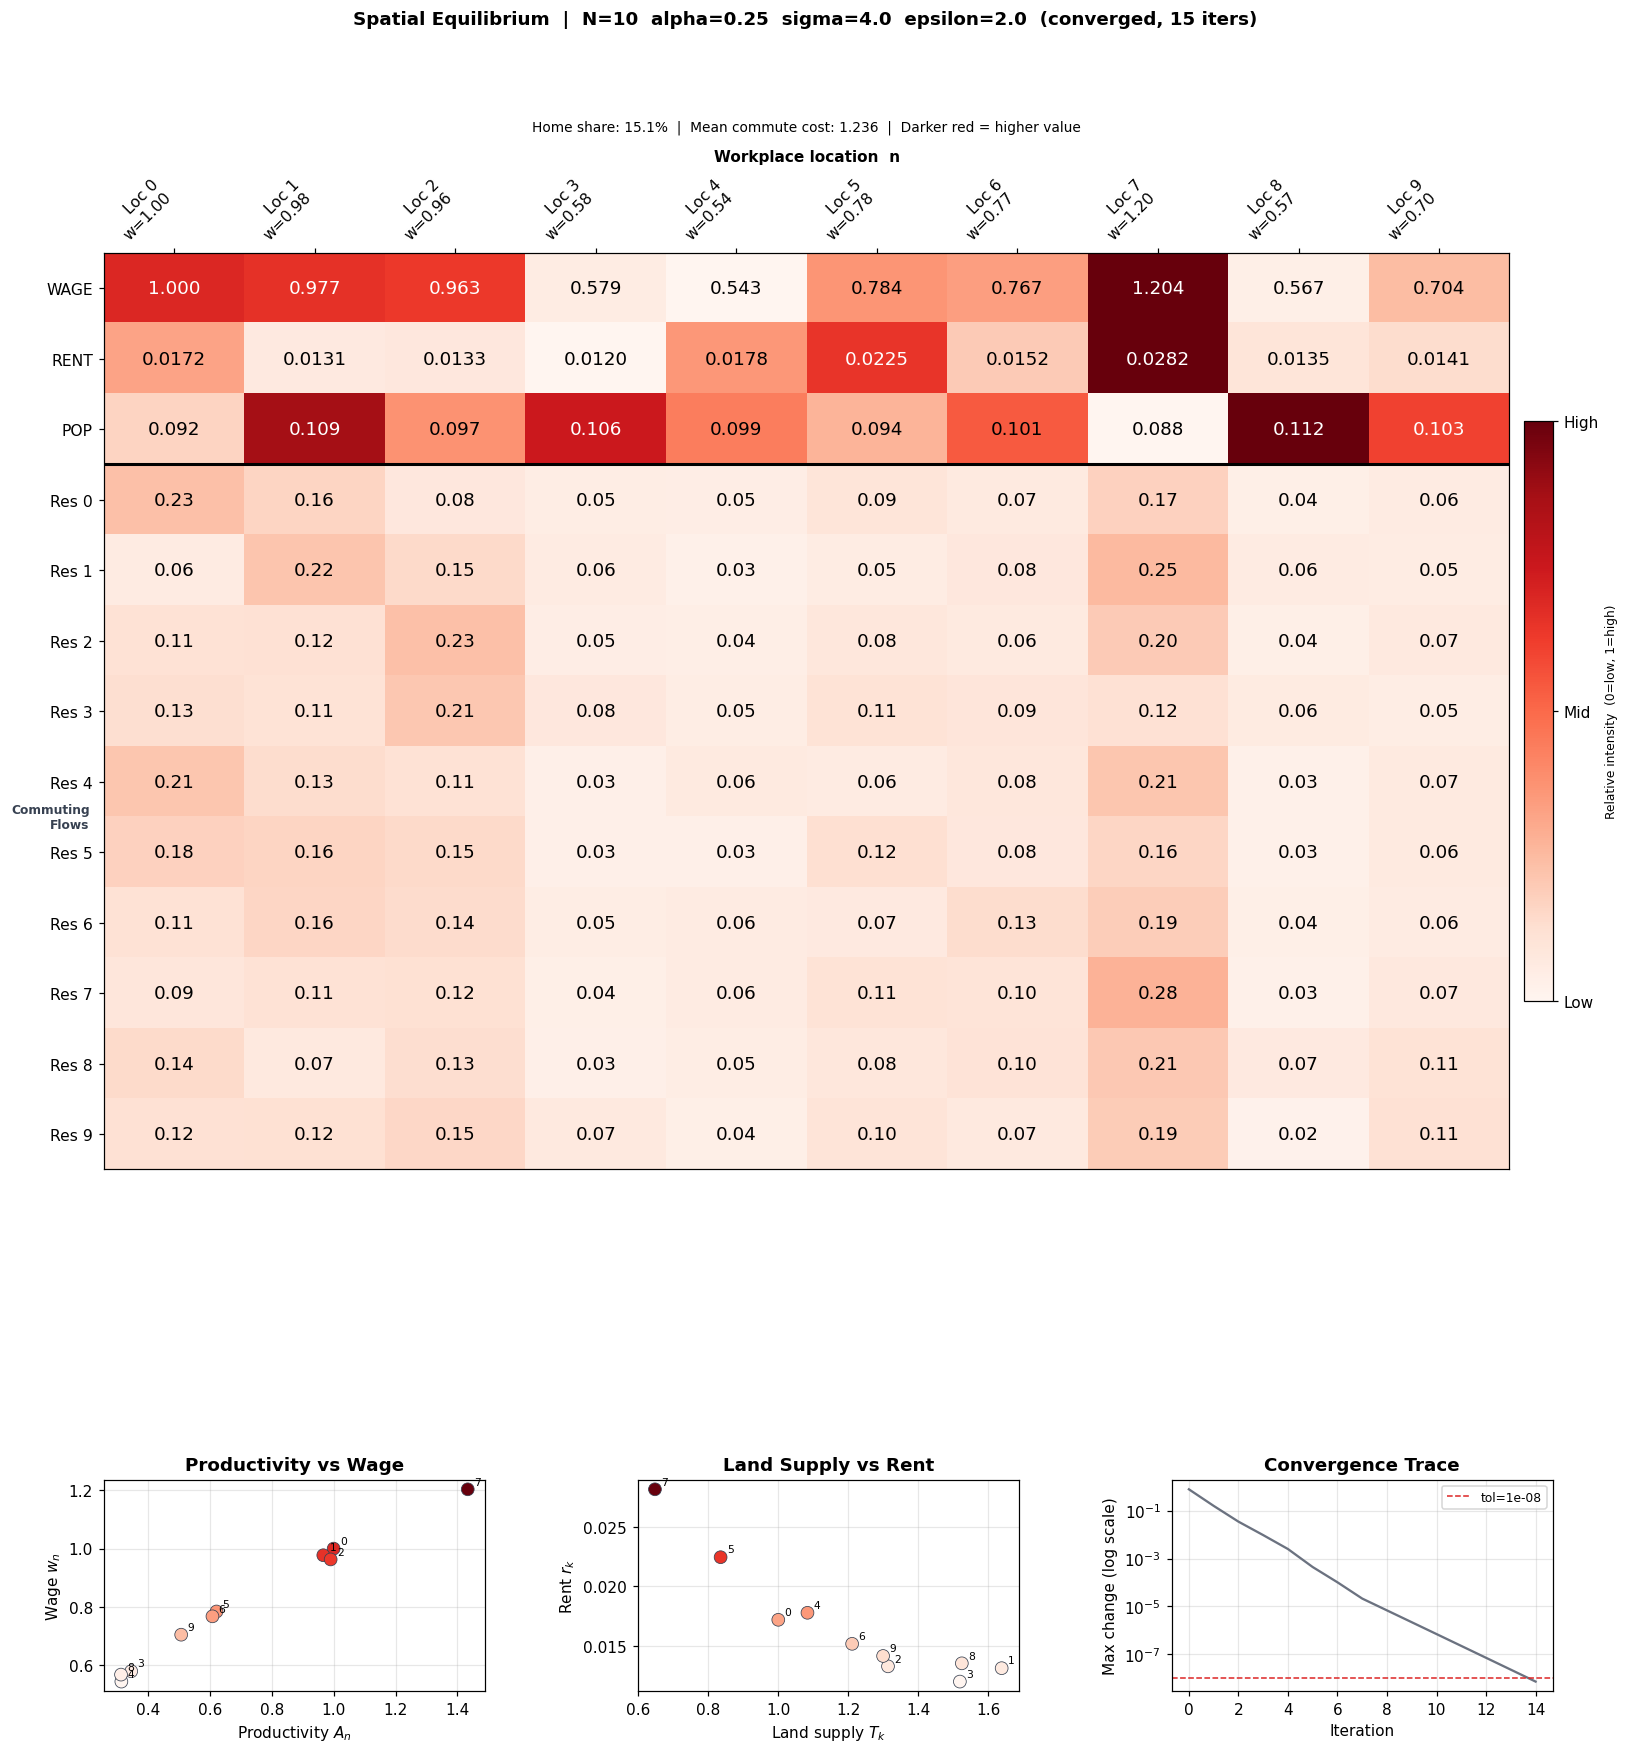

In [30]:
model  = SpatialModel(N=10, alpha=0.25, sigma=4.0, epsilon=2.0, seed=42)
solver = EquilibriumSolver(model, tol=1e-8, damping=0.8)
solver.solve()

analysis = SpatialAnalysis(model, solver)
analysis.print_location_stats()

fig = plot_equilibrium(model, solver)
plt.show()

## Interactive Dashboard
Drag the sliders, then press **Solve Model** to re-run the fixed-point iteration and redraw all plots.

Press **Comparative Statics** to sweep all four parameters automatically (takes ~10 seconds).

The **existence condition** updates live — if it exceeds 0.5 your parameter combination may not yield a unique equilibrium.

In [31]:
# ── Sliders ───────────────────────────────────────────────────────
style  = {'description_width': '50px'}
layout = widgets.Layout(width='440px')

w_N       = widgets.IntSlider(
    value=10, min=3, max=40, step=1, description='N',
    style=style, layout=layout)
w_alpha   = widgets.FloatSlider(
    value=0.25, min=0.05, max=0.50, step=0.05,
    description='alpha', readout_format='.2f', style=style, layout=layout)
w_sigma   = widgets.FloatSlider(
    value=4.0, min=1.5, max=8.0, step=0.5,
    description='sigma', readout_format='.1f', style=style, layout=layout)
w_epsilon = widgets.FloatSlider(
    value=2.0, min=0.5, max=6.0, step=0.5,
    description='epsilon', readout_format='.1f', style=style, layout=layout)
w_seed    = widgets.IntSlider(
    value=42, min=1, max=200, step=1, description='seed',
    style=style, layout=layout)

btn_solve = widgets.Button(
    description=' Solve Model', button_style='primary', icon='play',
    layout=widgets.Layout(width='160px', height='36px'))
btn_cs    = widgets.Button(
    description=' Comparative Statics', button_style='info', icon='bar-chart',
    layout=widgets.Layout(width='210px', height='36px'))

lbl_cond = widgets.HTML(value='')
out_main = widgets.Output()
out_cs   = widgets.Output()


def _refresh_condition(*args):
    """Recompute and display existence condition value as sliders move."""
    a   = (1 + w_epsilon.value) / (w_sigma.value + w_epsilon.value)
    b   = (w_alpha.value * w_epsilon.value) / (1 + w_alpha.value * w_epsilon.value)
    val = a * b
    ok  = val <= 0.5
    col = '#16A34A' if ok else '#DC2626'
    sym = '&#10003;' if ok else '&#10007;'
    txt = '&lt;= 0.5  (OK)' if ok else '&gt; 0.5  (WARNING: uniqueness not guaranteed)'
    lbl_cond.value = (
        f'<span style="color:{col}; font-size:13px; font-weight:bold;">'
        f'{sym} Existence condition: {val:.4f} {txt}</span>'
    )

for w in [w_N, w_alpha, w_sigma, w_epsilon]:
    w.observe(_refresh_condition, names='value')
_refresh_condition()


def on_solve(_):
    with out_main:
        clear_output(wait=True)
        print('Solving...')
        try:
            m = SpatialModel(
                N=w_N.value, alpha=w_alpha.value,
                sigma=w_sigma.value, epsilon=w_epsilon.value,
                seed=w_seed.value)
            s = EquilibriumSolver(m, tol=1e-8, max_iter=10_000, damping=0.8)
            s.solve()
            clear_output(wait=True)
            plot_equilibrium(m, s)
            plt.show()
            an = SpatialAnalysis(m, s)
            an.print_location_stats()
        except Exception as e:
            clear_output(wait=True)
            print(f'Error: {e}')


def on_cs(_):
    with out_cs:
        clear_output(wait=True)
        print('Running comparative statics — this takes about 10 seconds...')
        try:
            m  = SpatialModel(
                N=w_N.value, alpha=w_alpha.value,
                sigma=w_sigma.value, epsilon=w_epsilon.value,
                seed=w_seed.value)
            s  = EquilibriumSolver(m, tol=1e-8, damping=0.5)
            s.solve()
            an = SpatialAnalysis(m, s)
            clear_output(wait=True)
            plot_comparative_statics(an)
            plt.show()
        except Exception as e:
            clear_output(wait=True)
            print(f'Error: {e}')


btn_solve.on_click(on_solve)
btn_cs.on_click(on_cs)

panel = widgets.VBox([
    widgets.HTML('<b style="font-size:15px">Model Parameters</b>'),
    w_N, w_alpha, w_sigma, w_epsilon, w_seed,
    lbl_cond,
    widgets.HBox([btn_solve, btn_cs]),
])

display(panel, out_main, out_cs)
on_solve(None)  # auto-run once on load

Output()

Output()

## Save Figures to Disk
Edit the parameters below and run to save PNG files alongside this notebook.

/var/folders/xk/j0fncmqn7tzbwn308mxcl2q80000gn/T/ipykernel_29762/1683673315.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved  equilibrium.png
  Sweeping alpha...
  Sweeping sigma...
  Sweeping epsilon...
  Sweeping N...
Saved  comparative_statics.png


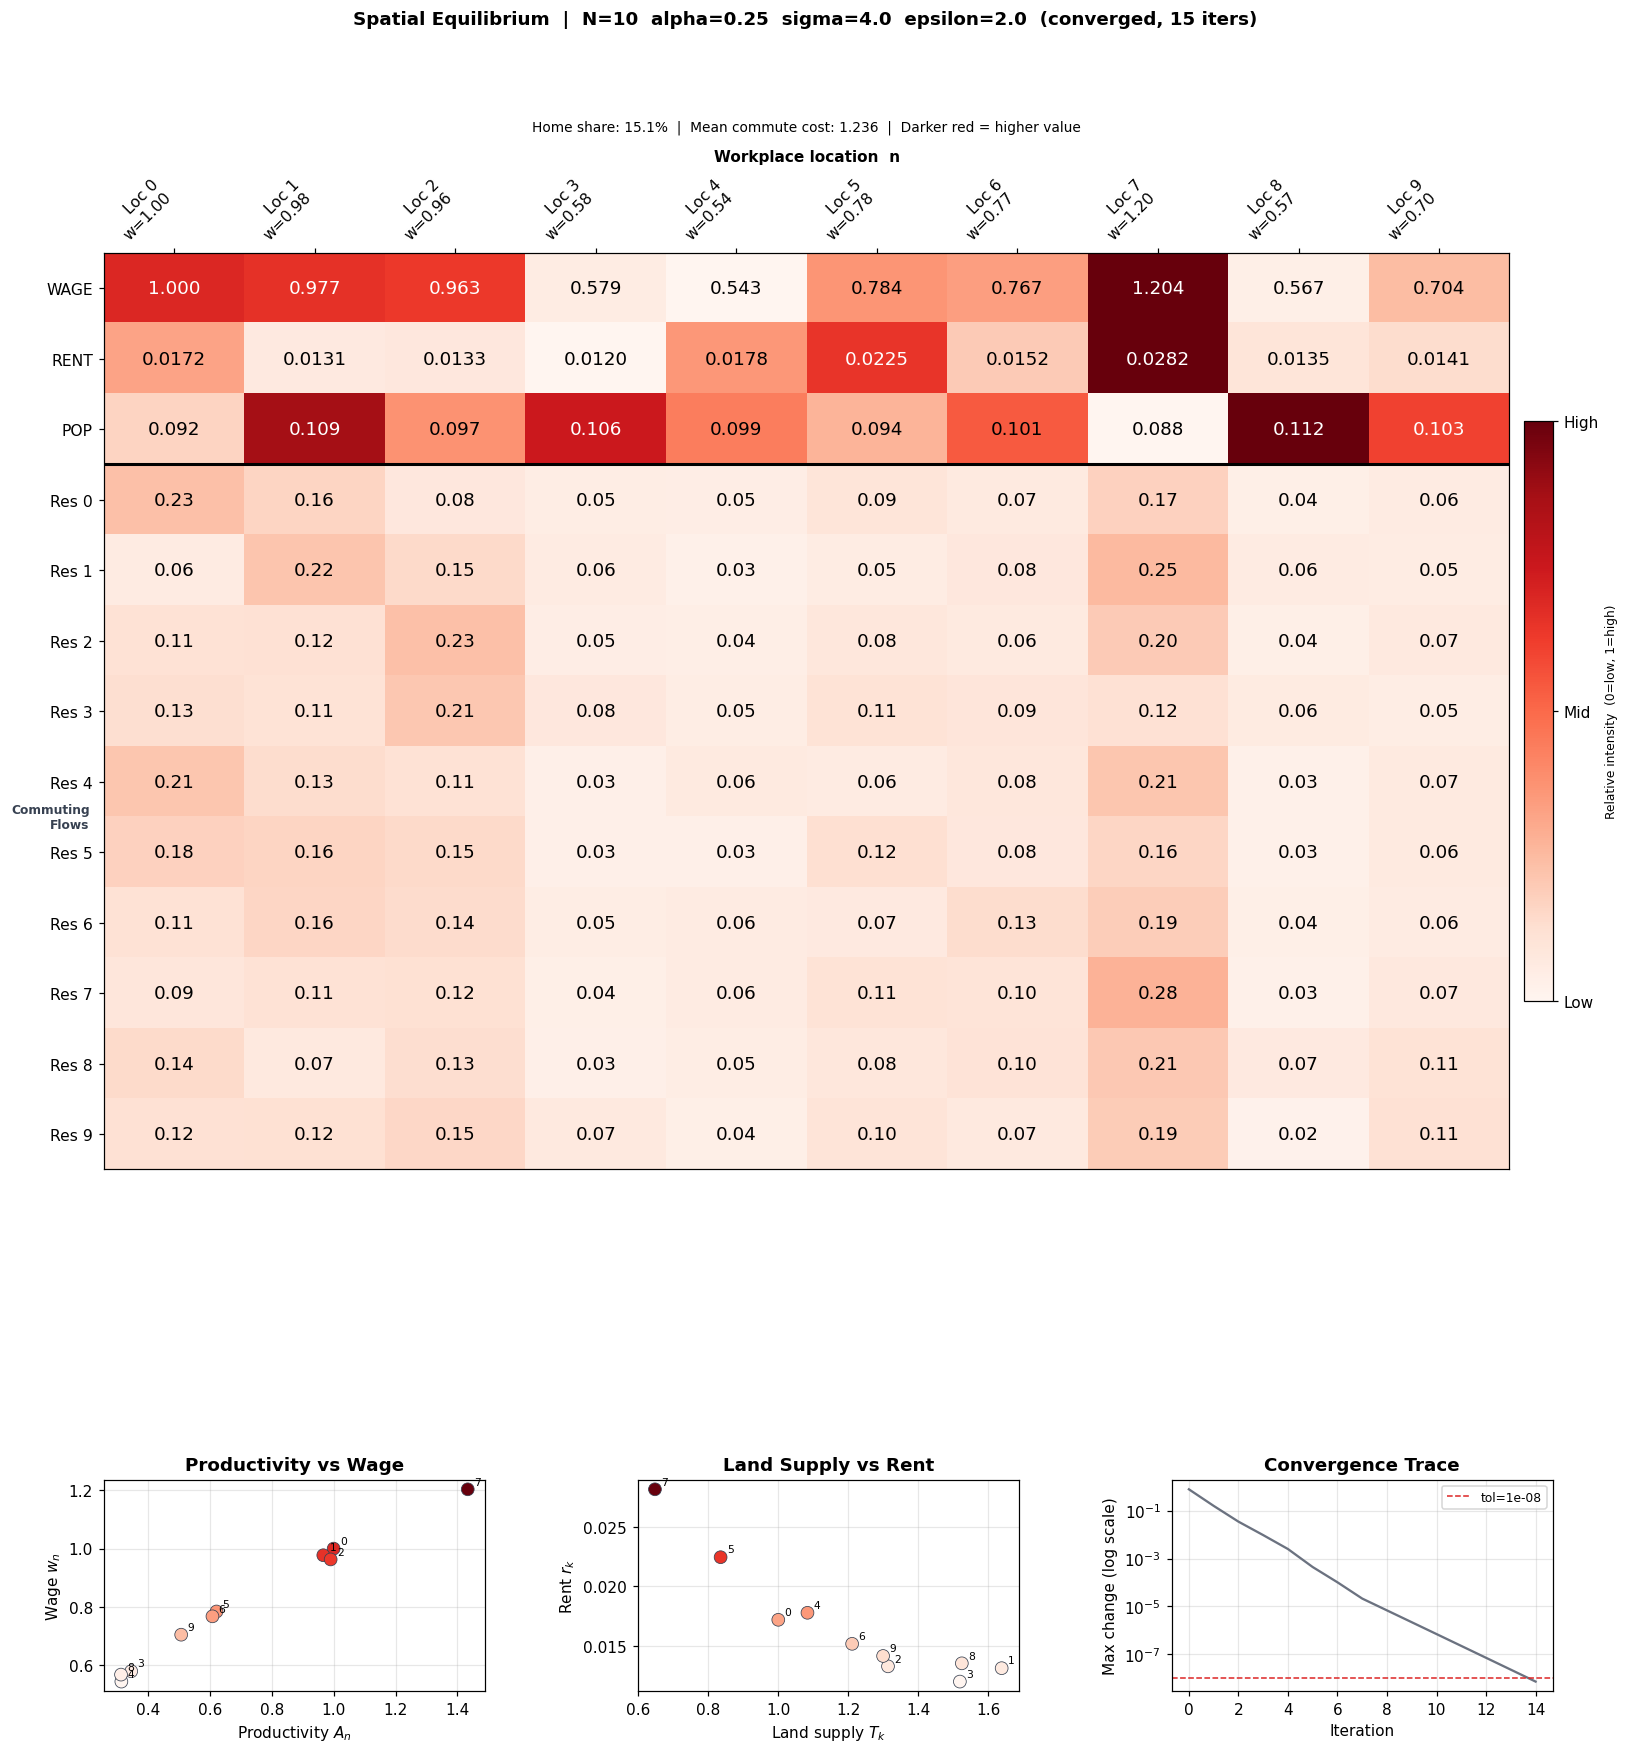

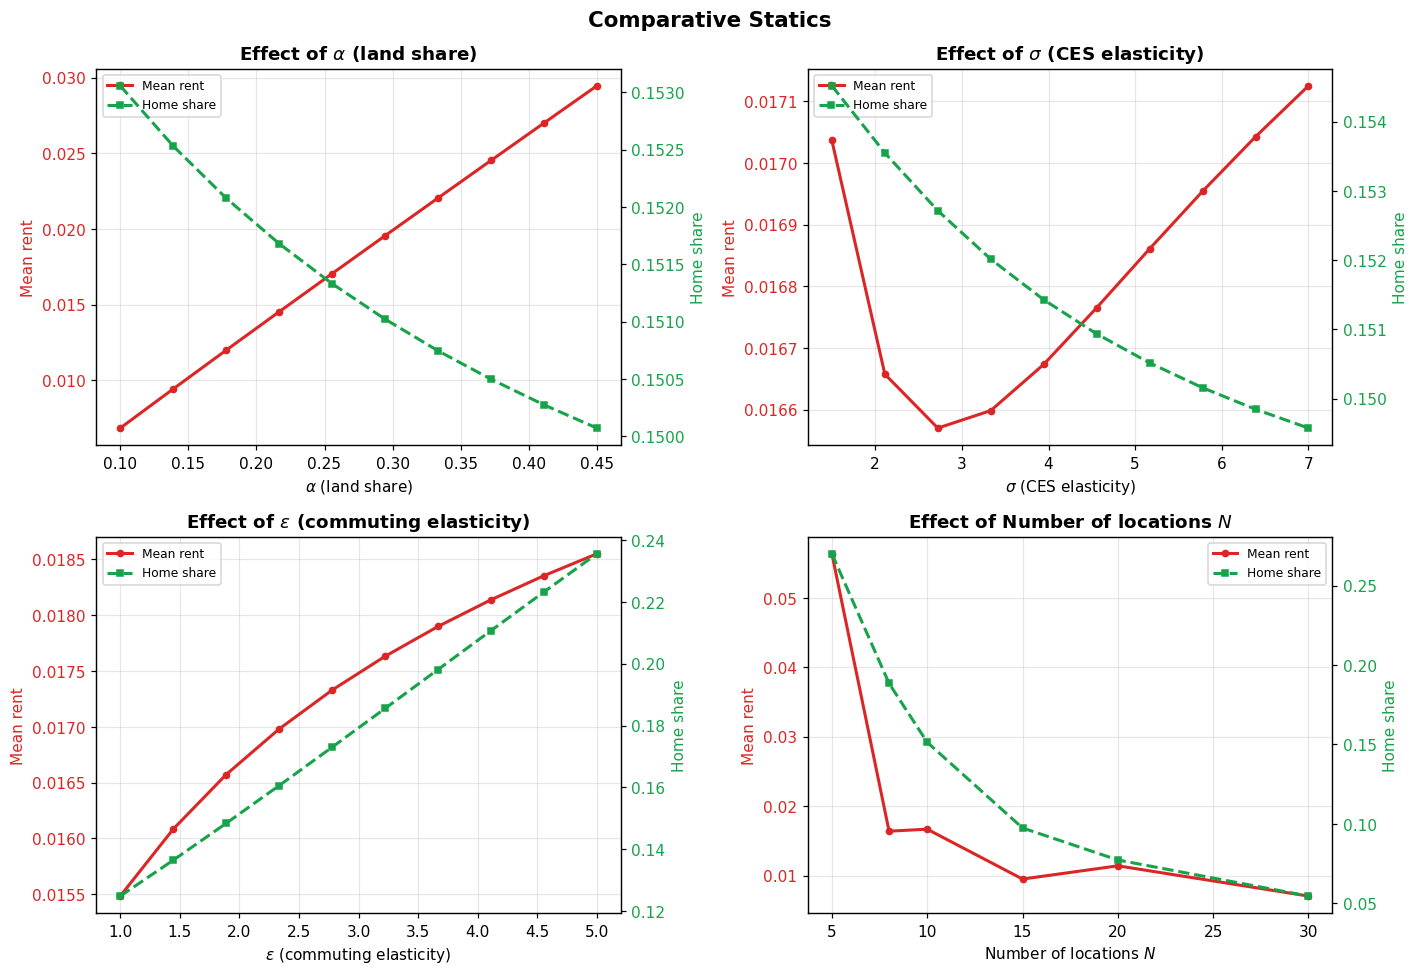

In [20]:
SAVE_N, SAVE_ALPHA, SAVE_SIGMA, SAVE_EPSILON, SAVE_SEED = 10, 0.25, 4.0, 2.0, 42

m_sv = SpatialModel(N=SAVE_N, alpha=SAVE_ALPHA, sigma=SAVE_SIGMA,
                     epsilon=SAVE_EPSILON, seed=SAVE_SEED)
s_sv = EquilibriumSolver(m_sv, tol=1e-8, damping=0.8)
s_sv.solve()

fig_eq = plot_equilibrium(m_sv, s_sv)
fig_eq.savefig('equilibrium.png', dpi=150, bbox_inches='tight')
print('Saved  equilibrium.png')

an_sv  = SpatialAnalysis(m_sv, s_sv)
fig_cs = plot_comparative_statics(an_sv)
fig_cs.savefig('comparative_statics.png', dpi=150, bbox_inches='tight')
print('Saved  comparative_statics.png')